<a href="https://colab.research.google.com/github/kendallfrederick/umud_challenge/blob/main/apo_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_d2a760e9c0b21e8e5d2147e657f460d7"

import kagglehub

# Download latest version
path = kagglehub.competition_download('umud-challenge-muscle-architecture-in-ultrasound-data')

print("Path to competition files:", path)

100%|██████████| 2.56G/2.56G [00:26<00:00, 103MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/umud-challenge-muscle-architecture-in-ultrasound-data


In [2]:
import glob
import os

base = "/root/.cache/kagglehub/competitions/umud-challenge-muscle-architecture-in-ultrasound-data"

apo_imgs = sorted(glob.glob(base + "/apo_imgs_v1/**/*.tif", recursive=True))
apo_masks = sorted(glob.glob(base + "/apo_masks_v1/**/*.tif", recursive=True))

fasc_imgs = sorted(glob.glob(base + "/fasc_imgs_v1/**/*.tif", recursive=True))
fasc_masks = sorted(glob.glob(base + "/fasc_masks_v1/**/*.tif", recursive=True))

test_imgs = sorted(glob.glob(base + "/test_images_v2/**/*.tif", recursive=True))

print("apo images:", len(apo_imgs))
print("apo masks:", len(apo_masks))
print("fasc images:", len(fasc_imgs))
print("fasc masks:", len(fasc_masks))
print("test images:", len(test_imgs))

apo images: 1048
apo masks: 1048
fasc images: 2761
fasc masks: 2761
test images: 251


In [3]:
import numpy as np
from PIL import Image

def foreground_fraction(mask_path):
    arr = np.asarray(Image.open(mask_path))
    # normalize to binary the same way your loader does

    binary = arr > (arr.max() / 2) if arr.max() > 0 else arr

    return binary.sum() / binary.size

def scan_masks(mask_paths, label):
    fracs = np.array([foreground_fraction(p) for p in mask_paths])
    suspicious = np.where(fracs > 0.5)[0]
    print(f"{label}: {len(suspicious)} / {len(mask_paths)} masks look inverted (foreground > 50%)")
    print(f"  fraction stats: min={fracs.min():.4f}, median={np.median(fracs):.4f}, max={fracs.max():.4f}")
    return fracs, suspicious

apo_fracs, apo_suspicious = scan_masks(apo_masks, "apo_masks")
fasc_fracs, fasc_suspicious = scan_masks(fasc_masks, "fasc_masks")

apo_masks: 474 / 1048 masks look inverted (foreground > 50%)
  fraction stats: min=0.0075, median=0.0561, max=0.9923
fasc_masks: 0 / 2761 masks look inverted (foreground > 50%)
  fraction stats: min=0.0000, median=0.0026, max=0.0111


In [4]:
import os
import shutil
import numpy as np
from PIL import Image

def invert(path):
    raw = np.asarray(Image.open(path))
    inverted = 255 - raw
    Image.fromarray(inverted).save(path)

def preprocess_masks(mask_paths, src_root, dst_root):
    out_paths = []
    for path in mask_paths:
        out_path = path.replace(src_root, dst_root)
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        shutil.copy(path, out_path)

        raw = np.asarray(Image.open(out_path))
        if raw.mean() > 255 / 2:
            invert(out_path)

        out_paths.append(out_path)
    return out_paths

apo_masks_clean = preprocess_masks(apo_masks, base + "/apo_masks_v1", "/kaggle/working/apo_masks_v1")
fasc_masks_clean = preprocess_masks(fasc_masks, base + "/fasc_masks_v1", "/kaggle/working/fasc_masks_v1")

In [5]:
# check that the apo masks were fixed
apo_fracs, apo_suspicious = scan_masks(apo_masks_clean, "apo_masks")

apo_masks: 0 / 1048 masks look inverted (foreground > 50%)
  fraction stats: min=0.0075, median=0.0306, max=0.1075


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Data augmentation layer
# Height and width shift, brightness, and rotation as done in DL Track
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

# Apply the same augmentation to both image and mask
def augment_image_mask(img, mask):
    # Combine image and mask along the channel dimension
    # Shape becomes: (batch, 512, 512, 2)
    combined = tf.concat([img, mask], axis=-1)

    # Apply the same random transformation to both
    combined = data_augmentation(combined, training=True)

    # Separate image and mask again
    img = combined[..., :1]
    mask = combined[..., 1:]

    # Make the mask binary again
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    return img, mask

In [8]:
IMG_SIZE = 512

def load_tiff_python(img_path, mask_path):
    img_path = img_path.numpy().decode("utf-8")
    mask_path = mask_path.numpy().decode("utf-8")

    img = load_img(img_path, color_mode="grayscale", target_size=(IMG_SIZE, IMG_SIZE))
    img = img_to_array(img).astype("float32") / 255.0

    mask = load_img(mask_path, color_mode="grayscale", target_size=(IMG_SIZE, IMG_SIZE))
    mask = img_to_array(mask).astype("float32") / 255.0
    mask = (mask > 0.5).astype("float32")

    return img, mask


def load_image_mask(img_path, mask_path):
    img, mask = tf.py_function(
        func=load_tiff_python,
        inp=[img_path, mask_path],
        Tout=[tf.float32, tf.float32]
    )

    img.set_shape((IMG_SIZE, IMG_SIZE, 1))
    mask.set_shape((IMG_SIZE, IMG_SIZE, 1))

    return img, mask

In [9]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import load_img, img_to_array

# Splits data into 80% for training and 20% for validation
apo_train_imgs, apo_val_imgs, apo_train_masks, apo_val_masks = train_test_split(
    apo_imgs,
    apo_masks_clean,
    test_size=0.2,
    random_state=42 # Makes the split reproducible
)

# How many images at a time
BATCH_SIZE = 8

#Creates a TensorFlow dataset from the image paths and mask paths
train_ds = tf.data.Dataset.from_tensor_slices((apo_train_imgs, apo_train_masks))
train_ds = train_ds.map(load_image_mask).shuffle(500).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((apo_val_imgs, apo_val_masks))
val_ds = val_ds.map(load_image_mask).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Augmented training dataset
train_ds_aug = train_ds.map(
    augment_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

In [10]:
# Dice coefficient measures how much the predicted mask overlaps with the true mask
# Higher Dice is better, with 1 meaning perfect overlap
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Flatten the masks so we compare all pixels together
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    # Count the overlapping pixels between the true and predicted masks
    intersection = tf.reduce_sum(y_true * y_pred)

    # Compute Dice score
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )


# Dice loss is the opposite of Dice score
# Lower Dice loss means better segmentation
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


# Combine binary crossentropy and Dice loss
# BCE helps with pixel-wise classification
# Dice helps with mask overlap
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)

    return bce + dice

In [11]:
# A convolutional block used throughout the U-Net.
# It applies two convolutional layers with ReLU activation.
def conv_block(x, filters):
    # First convolution
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)

    # Second convolution
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)

    return x

# Builds a U-Net model for binary image segmentation
def build_unet(input_shape=(512, 512, 1)):

    # Input layer (512x512 grayscale image)
    inputs = layers.Input(input_shape)

    # ---------------- Encoder ----------------
    # Extracts image features while reducing spatial resolution
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    # ---------------- Bottleneck ----------------
    # Deepest part of the network, where high-level features are learned
    bn = conv_block(p3, 256)

    # ---------------- Decoder ----------------
    # Reconstructs the segmentation mask by increasing image resolution

    # Upsample and combine with encoder features
    u3 = layers.UpSampling2D()(bn)
    u3 = layers.Concatenate()([u3, c3])
    c4 = conv_block(u3, 128)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = conv_block(u2, 64)

    u1 = layers.UpSampling2D()(c5)
    u1 = layers.Concatenate()([u1, c1])
    c6 = conv_block(u1, 32)


    # Output layer
    # Produces a single-channel probability map where each pixel
    # represents the probability of belonging to the target class
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c6)

    # Create and return the complete U-Net model
    return models.Model(inputs, outputs)

In [12]:
apo_model_dice = build_unet(input_shape=(512, 512, 1))

# Stop training if validation loss stops improving
# restore_best_weights=True keeps the best version of the model
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

# Compile the model with the improved loss and Dice metric
apo_model_dice.compile(
    optimizer="adam",
    loss=bce_dice_loss,
    metrics=["accuracy", dice_coef]
)

# Early stopping may stop it before 10 if it stops improving
history = apo_model_dice.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - accuracy: 0.9693 - dice_coef: 0.3863 - loss: 0.7472 - val_accuracy: 0.9786 - val_dice_coef: 0.5959 - val_loss: 0.4779
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 86s 699ms/step - accuracy: 0.9760 - dice_coef: 0.6144 - loss: 0.4760 - val_accuracy: 0.9781 - val_dice_coef: 0.6640 - val_loss: 0.4230
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 85s 707ms/step - accuracy: 0.9773 - dice_coef: 0.6341 - loss: 0.4516 - val_accuracy: 0.9786 - val_dice_coef: 0.6390 - val_loss: 0.4232
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 87s 717ms/step - accuracy: 0.9780 - dice_coef: 0.6474 - loss: 0.4369 - val_accuracy: 0.9803 - val_dice_coef: 0.6708 - val_loss: 0.4010
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 86s 711ms/step - accuracy: 0.9792 - dice_coef: 0.6609 - loss: 0.4193 - val_accuracy: 0.9795 - val_dice_coef: 0.6774 - val_loss: 0.3916
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 87s 720ms/step - accuracy: 0.9802 - dice_coef: 0.6769 - loss: 0.3998 - val_accuracy: 0.

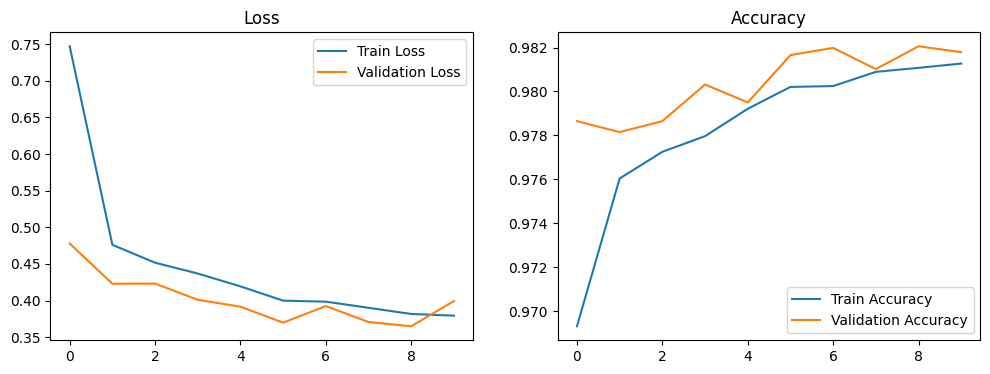

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy")
plt.legend()

plt.show()

In [15]:
# Save the already-trained model
apo_model_dice.save("inverted_apo_model.keras")

In [27]:
apo_model_dice.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ conv2d_9[0][0]  

 Total params: 5,838,917 (22.27 MB)

 Trainable params: 1,946,305 (7.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,892,612 (14.85 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


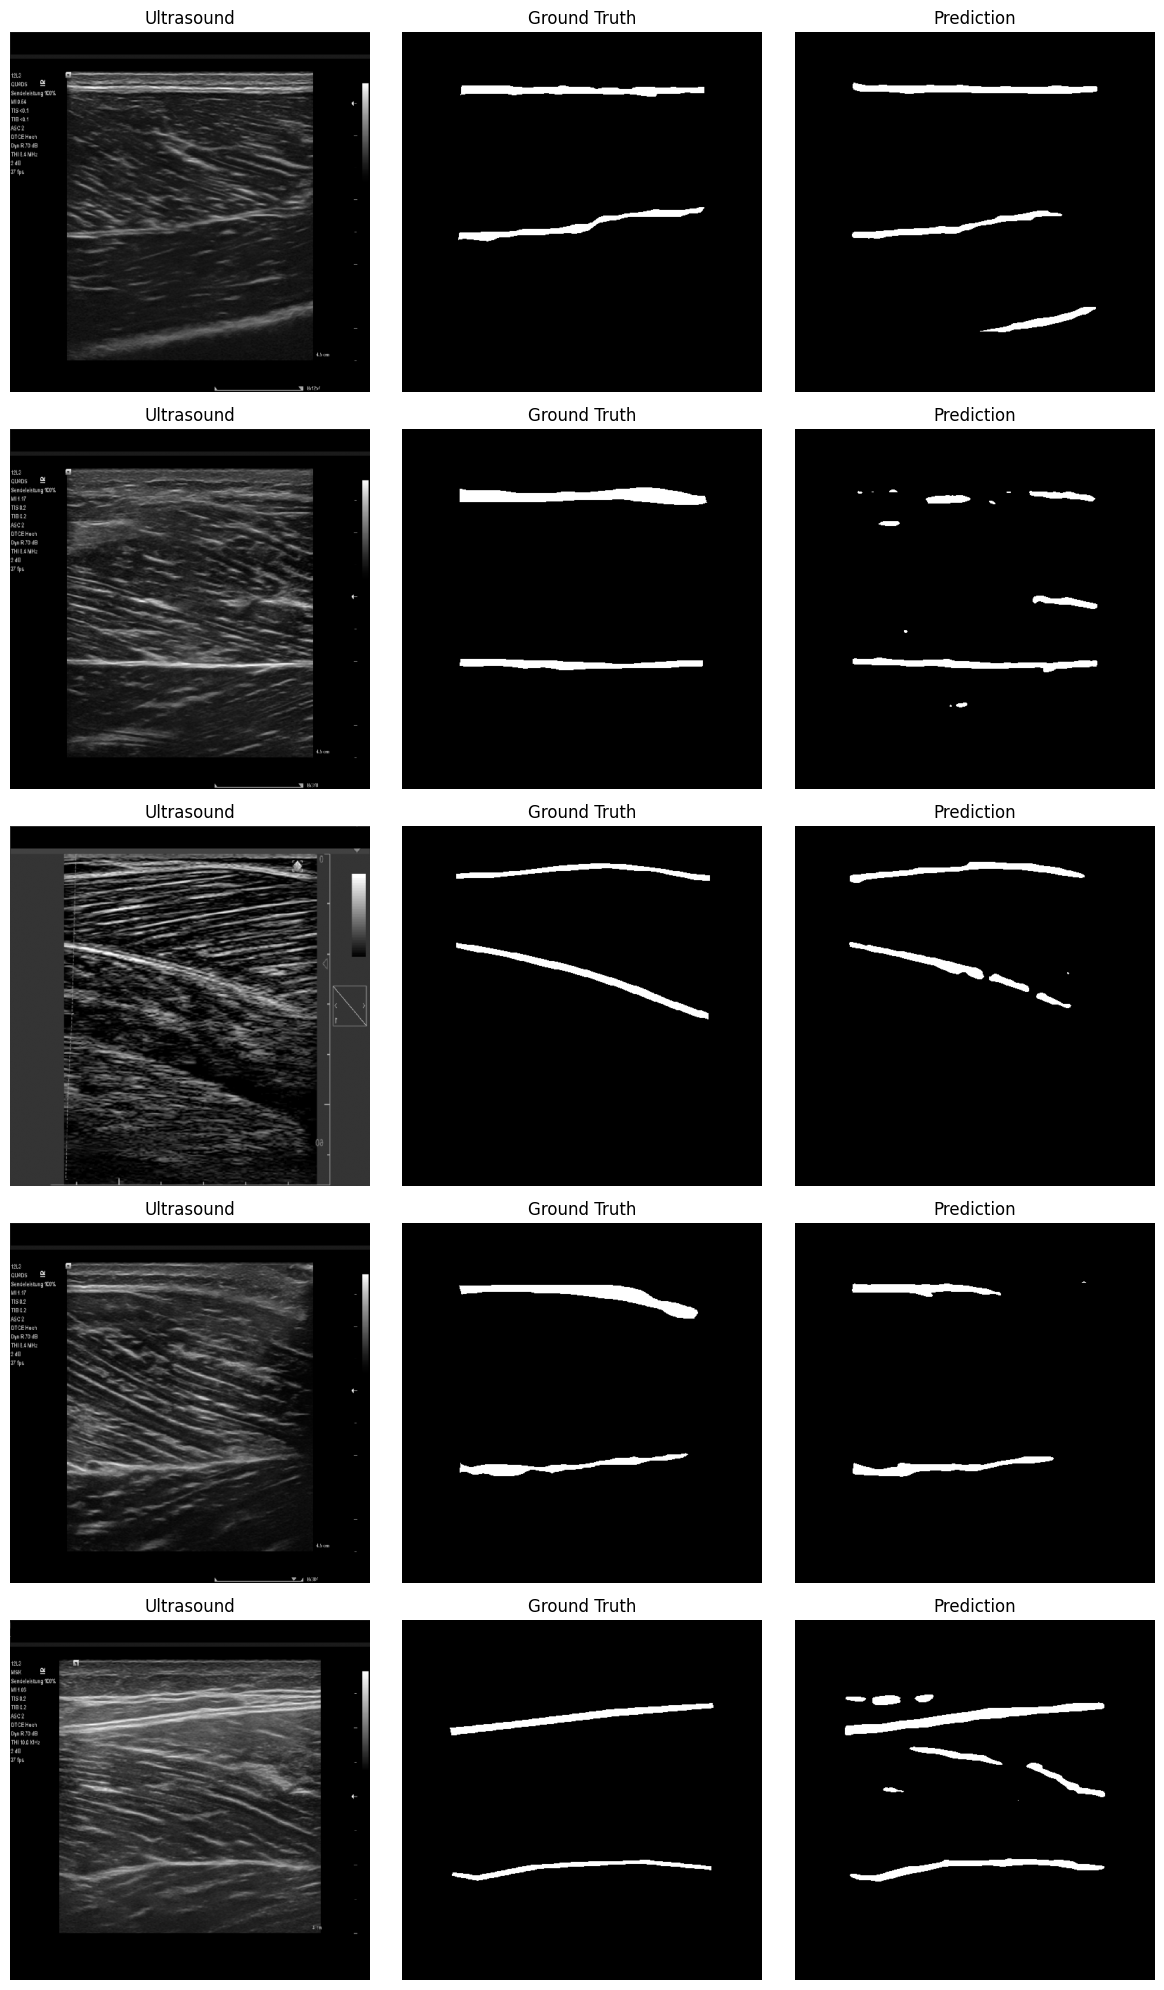

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from the validation set
imgs, masks = next(iter(val_ds))

# Predict masks
preds = apo_model_dice.predict(imgs)

# Convert probabilities to binary masks
preds = (preds > 0.5).astype(np.uint8)

# Number of images to display
num_images = min(5, len(imgs))

plt.figure(figsize=(12, 4 * num_images))

for i in range(num_images):

    # Original ultrasound
    plt.subplot(num_images, 3, 3*i + 1)
    plt.imshow(imgs[i].numpy().squeeze(), cmap="gray")
    plt.title("Ultrasound")
    plt.axis("off")

    # Ground truth
    plt.subplot(num_images, 3, 3*i + 2)
    plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(num_images, 3, 3*i + 3)
    plt.imshow(preds[i].squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Conv2D, UpSampling2D, Activation, BatchNormalization,
    add, multiply, Lambda
)

def expend_as(tensor, rep):
    # repeats along the channel axis (axis=3 in 2D: batch, H, W, C)
    return Lambda(lambda x, repnum: K.repeat_elements(x, repnum, axis=3),
                  arguments={'repnum': rep})(tensor)

def AttnGatingBlock(x, g, inter_shape):
    shape_x = K.int_shape(x)  # (batch, H, W, C) -- the skip connection (encoder feature)
    shape_g = K.int_shape(g)  # (batch, H, W, C) -- the gating signal (decoder/bottleneck feature)

    # Bring gating signal to inter_shape filters
    phi_g = Conv2D(filters=inter_shape, kernel_size=1, strides=1, padding='same')(g)

    # Bring x down to the same spatial size as g, at inter_shape filters
    theta_x = Conv2D(filters=inter_shape, kernel_size=3,
                      strides=(shape_x[1] // shape_g[1], shape_x[2] // shape_g[2]),
                      padding='same')(x)

    add_xg = add([phi_g, theta_x])
    add_xg = Activation('relu')(add_xg)

    psi = Conv2D(filters=1, kernel_size=1, padding='same')(add_xg)
    psi = Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(psi)

    # Upsample attention map back to x's spatial resolution
    upsample_psi = UpSampling2D(size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(psi)
    upsample_psi = expend_as(upsample_psi, shape_x[3])  # broadcast to x's channel count

    attn_coefficients = multiply([upsample_psi, x])

    output = Conv2D(filters=shape_x[3], kernel_size=1, strides=1, padding='same')(attn_coefficients)
    output = BatchNormalization()(output)
    return output

# A convolutional block used throughout the U-Net.
# It applies two convolutional layers with ReLU activation.
def conv_block(x, filters):
    # First convolution
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)

    # Second convolution
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)

    return x

In [25]:
def build_unet(input_shape=(512, 512, 1)):
    inputs = layers.Input(input_shape)

    # ---------------- Encoder ----------------
    c1 = conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    # ---------------- Bottleneck ----------------
    bn = conv_block(p3, 256)

    # ---------------- Decoder with attention gates ----------------
    g3 = layers.UpSampling2D()(bn)              # upsample gating signal to c3's resolution
    a3 = AttnGatingBlock(c3, bn, inter_shape=128)  # gate c3 using bn as the coarser signal
    u3 = layers.Concatenate()([g3, a3])
    c4 = conv_block(u3, 128)

    g2 = layers.UpSampling2D()(c4)
    a2 = AttnGatingBlock(c2, c4, inter_shape=64)
    u2 = layers.Concatenate()([g2, a2])
    c5 = conv_block(u2, 64)

    g1 = layers.UpSampling2D()(c5)
    a1 = AttnGatingBlock(c1, c5, inter_shape=32)
    u1 = layers.Concatenate()([g1, a1])
    c6 = conv_block(u1, 32)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c6)

    return models.Model(inputs, outputs)

In [26]:
apo_attention = build_unet(input_shape=(512, 512, 1))

In [28]:
apo_attention.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 512, 512,  │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 512, 512,  │      9,248 │ conv2d_30[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 256, 256,  │          0 │ conv2d_31[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 256, 256,  │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_32[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 128, 128,  │          0 │ conv2d_33[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 128, 128,  │    147,584 │ conv2d_34[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 64,    │          0 │ conv2d_35[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_8[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_36[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 64, 64,    │     32,896 │ conv2d_37[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_35[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ conv2d_38[0][0],  │
│                     │ 128)              │            │ conv2d_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ add[0][0]         │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 64, 64, 1) │        129 │ activation[0][0]

 Total params: 2,206,148 (8.42 MB)

 Trainable params: 2,205,700 (8.41 MB)

 Non-trainable params: 448 (1.75 KB)

In [29]:
# Stop training if validation loss stops improving
# restore_best_weights=True keeps the best version of the model
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

# Compile the model with the improved loss and Dice metric
apo_attention.compile(
    optimizer="adam",
    loss=bce_dice_loss,
    metrics=["accuracy", dice_coef]
)

history = apo_attention.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9565 - dice_coef: 0.4703 - loss: 0.6750 - val_accuracy: 0.9679 - val_dice_coef: 0.0049 - val_loss: 1.1902
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 102s 820ms/step - accuracy: 0.9750 - dice_coef: 0.6058 - loss: 0.4867 - val_accuracy: 0.9679 - val_dice_coef: 0.0102 - val_loss: 1.1684
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 138s 824ms/step - accuracy: 0.9772 - dice_coef: 0.6341 - loss: 0.4536 - val_accuracy: 0.9679 - val_dice_coef: 0.0293 - val_loss: 1.1259
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 99s 834ms/step - accuracy: 0.9784 - dice_coef: 0.6529 - loss: 0.4297 - val_accuracy: 0.9692 - val_dice_coef: 0.1488 - val_loss: 0.9665
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 99s 837ms/step - accuracy: 0.9786 - dice_coef: 0.6570 - loss: 0.4264 - val_accuracy: 0.9778 - val_dice_coef: 0.4826 - val_loss: 0.5830
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 100s 844ms/step - accuracy: 0.9795 - dice_coef: 0.6670 - loss: 0.4116 - val_accuracy:

In [30]:
# Save the already-trained model
apo_attention.save("inverted_apo_attention.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step


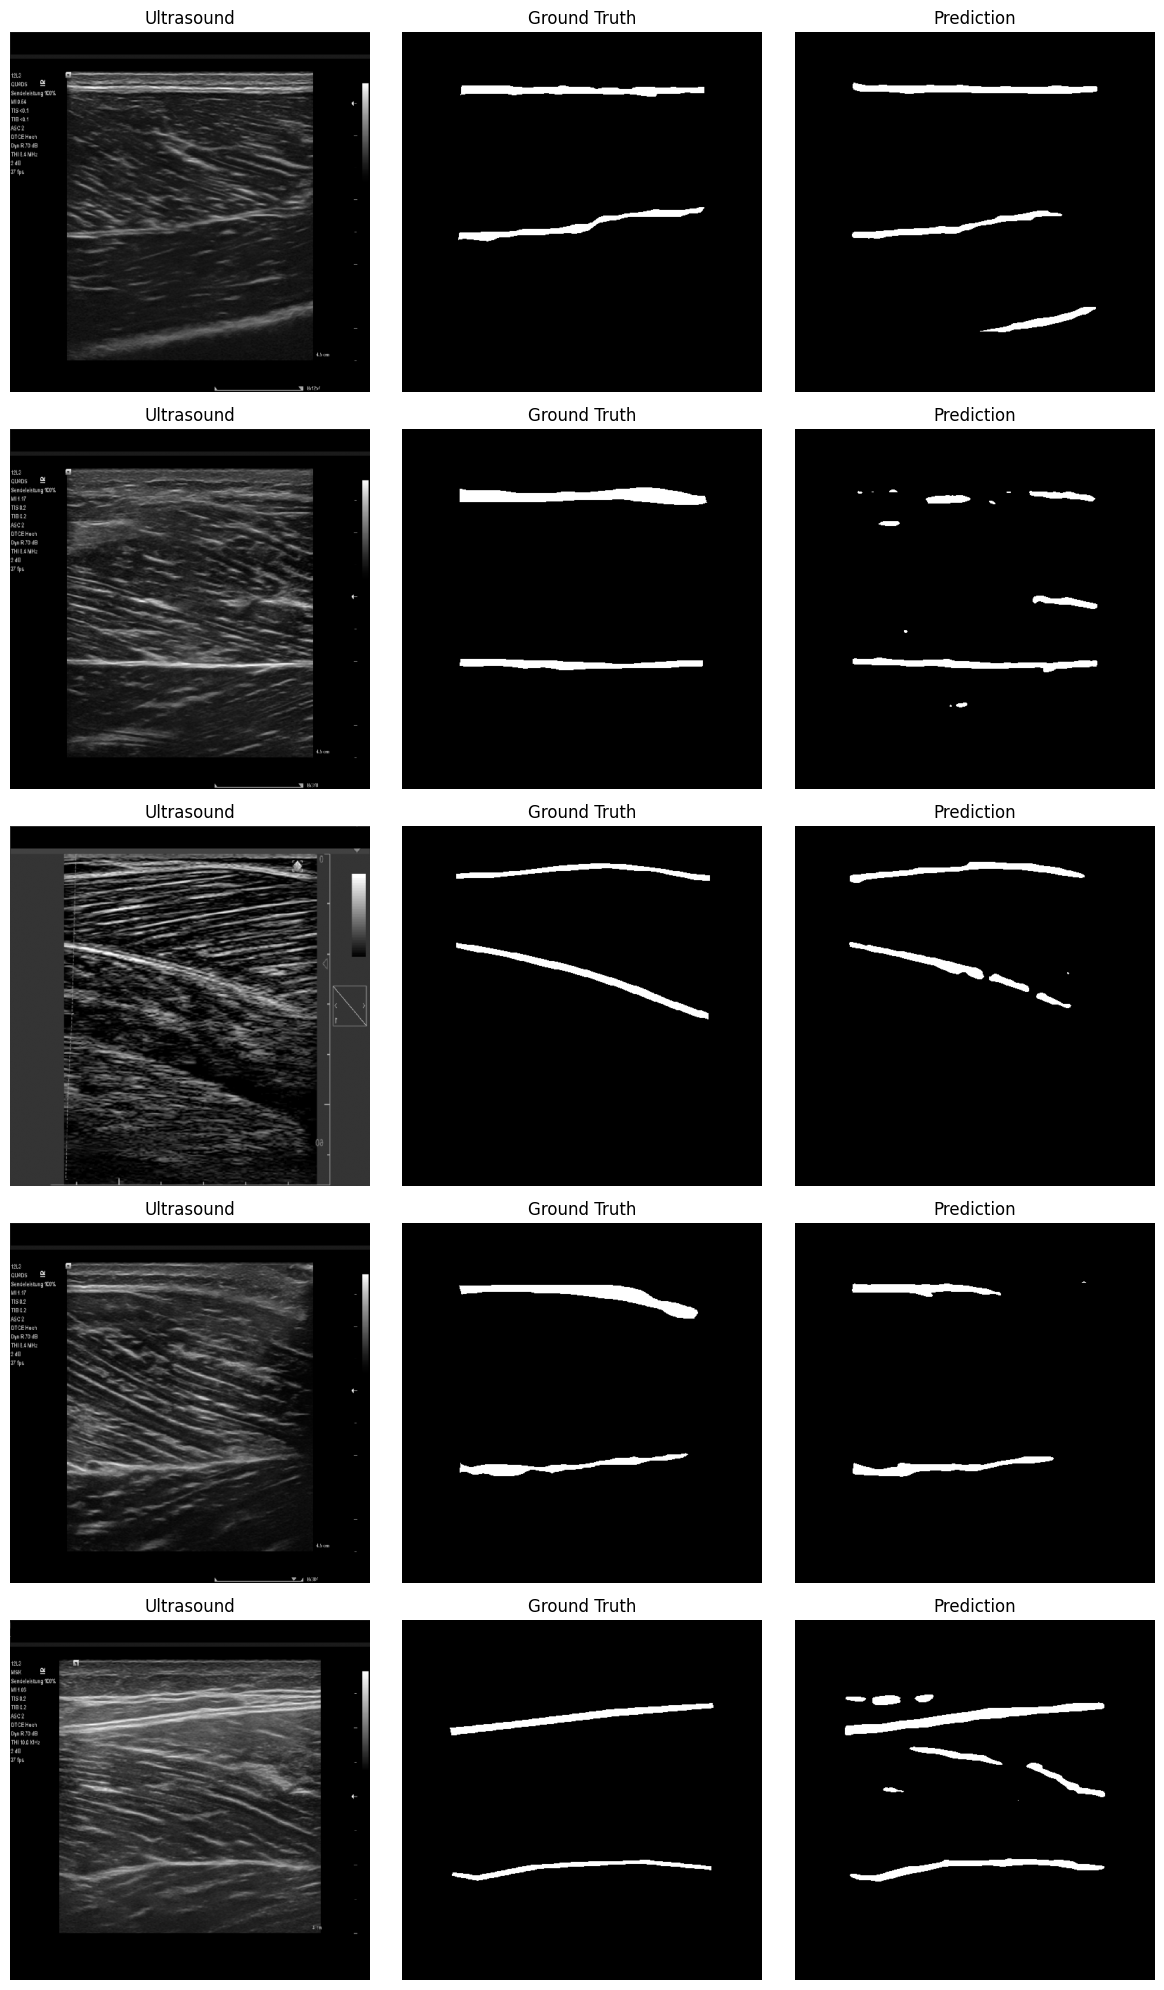

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from the validation set
imgs, masks = next(iter(val_ds))

# Predict masks
preds = apo_model_dice.predict(imgs)

# Convert probabilities to binary masks
preds = (preds > 0.5).astype(np.uint8)

# Number of images to display
num_images = min(5, len(imgs))

plt.figure(figsize=(12, 4 * num_images))

for i in range(num_images):

    # Original ultrasound
    plt.subplot(num_images, 3, 3*i + 1)
    plt.imshow(imgs[i].numpy().squeeze(), cmap="gray")
    plt.title("Ultrasound")
    plt.axis("off")

    # Ground truth
    plt.subplot(num_images, 3, 3*i + 2)
    plt.imshow(masks[i].numpy().squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(num_images, 3, 3*i + 3)
    plt.imshow(preds[i].squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()